In [1]:
!pip install scikit-learn
from sklearn.model_selection import train_test_split
import requests
import pandas as pd
from tqdm import tqdm
import tmdbdata as td
import random

Récupération des données 

In [8]:
df=td.get_movies_info(random.sample(range(0, 10000), 30),headers=td.headers)

getting movie info


100%|██████████| 30/30 [00:07<00:00,  3.92it/s]


In [9]:
df.head()

,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,video,vote_average,vote_count,belongs_to_collection.id,belongs_to_collection.name,belongs_to_collection.poster_path,belongs_to_collection.backdrop_path,success,status_code,status_message
0,False,None,None,0.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",,4684.0,tt0085264,[DE],de,...,False,4.500,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,True,None,None,0.0,"[{'id': 99, 'name': 'Documentary'}]",,5771.0,tt0402564,[US],en,...,False,0.000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,False,/JrQJCQnE5DEowyK88AS6VdEKVd.jpg,NaN,0.0,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",,2983.0,tt0104759,"[CA, US]",en,...,False,5.200,22.0,585662.0,The Lost World Collection,/4gCLlsfIN6zXssArfvSgVSzojJG.jpg,/1eTcbHcFzPE2WbPSl0AKwcNM2K.jpg,NaN,NaN,NaN
3,False,None,None,0.0,"[{'id': 18, 'name': 'Drama'}]",,2301.0,tt0081844,[DE],de,...,False,10.000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,False,/qKkSrN52k5XXltaBhhBMWKqqIdG.jpg,None,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 36, 'name...",,4483.0,tt0084589,[FR],fr,...,False,6.643,182.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df1=td.drop_useless_info(df)
df1=td.keep_main_genre(df1)

df1=td.full_poster_path(df1)

df1.head()
df1.describe()
df1.shape


(18, 13)

In [11]:
df1.head()

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path
0,0.0,4684.0,"Pete is no stranger to success, delivering hit...",1.372,1985-11-01,0.0,103.0,Bolero,4.500,2.0,35,Comedy,NaN
1,0.0,5771.0,,0.000,1980-03-01,0.0,30.0,Uschi,0.000,0.0,99,Documentary,NaN
2,0.0,2983.0,"Unfazed by ridicule from fellow scientists, pr...",3.779,1992-01-01,0.0,99.0,The Lost World,5.200,22.0,12,Adventure,https://image.tmdb.org/t/p/original//jJQovqiut...
3,0.0,2301.0,,0.928,1981-12-06,0.0,181.0,Collin,10.000,1.0,18,Drama,https://image.tmdb.org/t/p/original//xYqAfCDhd...
5,0.0,4483.0,"Village of Artigat, southern France, summer 15...",12.605,1982-05-14,0.0,107.0,The Return of Martin Guerre,6.643,182.0,18,Drama,https://image.tmdb.org/t/p/original//k6XfHExAs...


On remarque que qu'il y'a des données où le budget n'est pas renseigné, en effet on a min budget égal à 0.

In [ ]:
df1=df1.loc[df1["budget"]!=0] # on supprime les lignes où le budget n'est pas renseigné, l'imputation est possible par le budget moyen, pour le moment on fait le choix de ne pas imputer
df1=df1.loc[df1["revenue"]!=0]
df1.shape

(109, 13)

On va créer une colonne comptant le nombre de mots caractères dans le synopsis 

In [ ]:
df1["overview_count"]=df1["overview"].map(len)
df1.head()
df1.shape

(109, 14)

Nous allons encoder les genres pour la regression linéaire : méthode one hot encoding

In [ ]:
df1

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,main_genre_id,main_genre_name,full_poster_path,overview_count
6,5000000.0,9844.0,A 16-year-old girl visits her gay half-brother...,15.935,1998-05-22,5879254.0,105.0,The Opposite of Sex,6.100,197.0,35,Comedy,https://image.tmdb.org/t/p/original//xpILzxKHy...,125
15,16000000.0,2028.0,"Lloyd, an eternal optimist, seeks to capture t...",52.326,1989-04-14,20036737.0,100.0,Say Anything...,7.051,986.0,10749,Romance,https://image.tmdb.org/t/p/original//f6ffRzF8I...,332
18,85000000.0,7484.0,"Boog, a domesticated 900lb. Grizzly bear finds...",26.520,2006-09-27,197300000.0,86.0,Open Season,6.200,2729.0,16,Animation,https://image.tmdb.org/t/p/original//w5Lctmkc1...,291
21,3000000.0,8052.0,A stranger mentors a young Reno gambler who we...,17.053,1997-02-28,222559.0,102.0,Hard Eight,6.871,841.0,18,Drama,https://image.tmdb.org/t/p/original//1l5UaoP25...,96
28,1488423.0,408.0,"A beautiful girl, Snow White, takes refuge in ...",50.136,1938-01-14,184925486.0,83.0,Snow White and the Seven Dwarfs,7.121,7390.0,14,Fantasy,https://image.tmdb.org/t/p/original//3VAHfuNb6...,256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,98000000.0,1734.0,"Rick and Evelyn O’Connell, along with their 8-...",50.028,2001-05-04,443280904.0,130.0,The Mummy Returns,6.375,7008.0,12,Adventure,https://image.tmdb.org/t/p/original//kdJsW7hcy...,328
476,11600000.0,7010.0,A British multinational company seeks to overt...,8.662,1978-06-28,9900000.0,134.0,The Wild Geese,6.818,253.0,28,Action,https://image.tmdb.org/t/p/original//mUbbYSH0r...,451
478,52000000.0,9767.0,Pushed to the breaking-up point after their la...,21.054,2006-06-01,205700000.0,106.0,The Break-Up,5.900,2652.0,10749,Romance,https://image.tmdb.org/t/p/original//yN3b4ElUO...,519
483,80000000.0,310.0,"Bruce Nolan toils as a ""human interest"" televi...",47.244,2003-05-23,484600000.0,101.0,Bruce Almighty,6.716,10666.0,14,Fantasy,https://image.tmdb.org/t/p/original//3XJKBKh9K...,314


In [ ]:
df1["main_genre_name"].unique() 

array(['Comedy', 'Romance', 'Animation', 'Drama', 'Fantasy', 'Adventure',
       'Action', 'Crime', 'Western', 'Thriller', 'Horror', 'Music',
       'Mystery', 'Documentary', 'Science Fiction', 'Family'],
      dtype=object)

In [ ]:
#Méthode : OneHotEncoder
for genre in df1["main_genre_name"].unique() :
    df1["main_genre_name"+"_"+str(genre)] = (df1["main_genre_name"] == genre).astype(int) 
df1.shape
df1.head()

,budget,id,overview,popularity,release_date,revenue,runtime,title,vote_average,vote_count,...,main_genre_name_Action,main_genre_name_Crime,main_genre_name_Western,main_genre_name_Thriller,main_genre_name_Horror,main_genre_name_Music,main_genre_name_Mystery,main_genre_name_Documentary,main_genre_name_Science Fiction,main_genre_name_Family
6,5000000.0,9844.0,A 16-year-old girl visits her gay half-brother...,15.935,1998-05-22,5879254.0,105.0,The Opposite of Sex,6.100,197.0,...,0,0,0,0,0,0,0,0,0,0
15,16000000.0,2028.0,"Lloyd, an eternal optimist, seeks to capture t...",52.326,1989-04-14,20036737.0,100.0,Say Anything...,7.051,986.0,...,0,0,0,0,0,0,0,0,0,0
18,85000000.0,7484.0,"Boog, a domesticated 900lb. Grizzly bear finds...",26.520,2006-09-27,197300000.0,86.0,Open Season,6.200,2729.0,...,0,0,0,0,0,0,0,0,0,0
21,3000000.0,8052.0,A stranger mentors a young Reno gambler who we...,17.053,1997-02-28,222559.0,102.0,Hard Eight,6.871,841.0,...,0,0,0,0,0,0,0,0,0,0
28,1488423.0,408.0,"A beautiful girl, Snow White, takes refuge in ...",50.136,1938-01-14,184925486.0,83.0,Snow White and the Seven Dwarfs,7.121,7390.0,...,0,0,0,0,0,0,0,0,0,0


Nous allons essayer de prédire la note c'est à dire vote_average à partir des variables suivantes :

In [ ]:
df1["main_genre_name"].unique()
L=[]
for i in df1["main_genre_name"].unique() : 
    L.append("main_genre_name"+"_"+str(i))
print(L)

var_explicative=["id","vote_average","budget","runtime","overview_count","revenue"]
var_explicative.extend(L)
df1=df1.loc[:,var_explicative]
df1.head(1)


KeyError: 'main_genre_name'

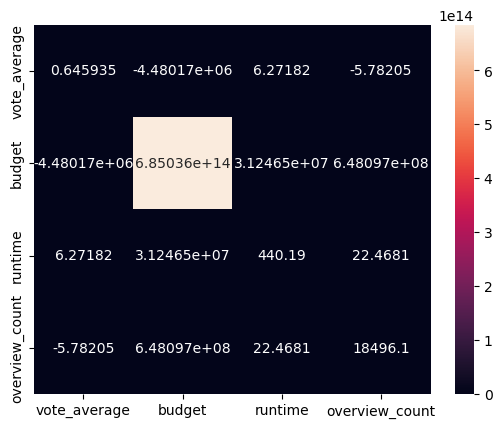

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cov = np.cov(df1.loc[:,["vote_average","budget","runtime","overview_count"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count"]

sns.heatmap(cov, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()


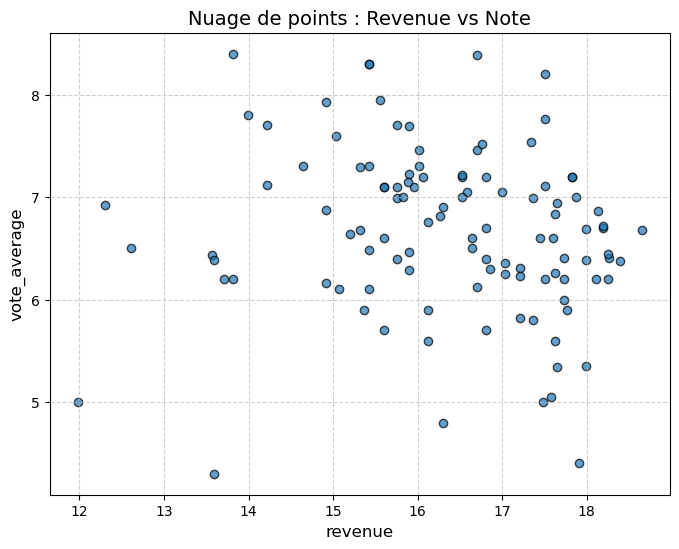

In [ ]:
import matplotlib.pyplot as plt

# Tracer le nuage de points
plt.figure(figsize=(8, 6))
plt.scatter(np.log(df1['budget']), df1['vote_average'], alpha=0.7, edgecolor='k')

# Ajouter des labels et un titre
plt.title("Nuage de points : Revenue vs Note", fontsize=14)
plt.xlabel("revenue", fontsize=12)
plt.ylabel("vote_average", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Afficher le graphique
plt.show()

/tmp/ipykernel_11127/712210021.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue"]].T, bias=True)


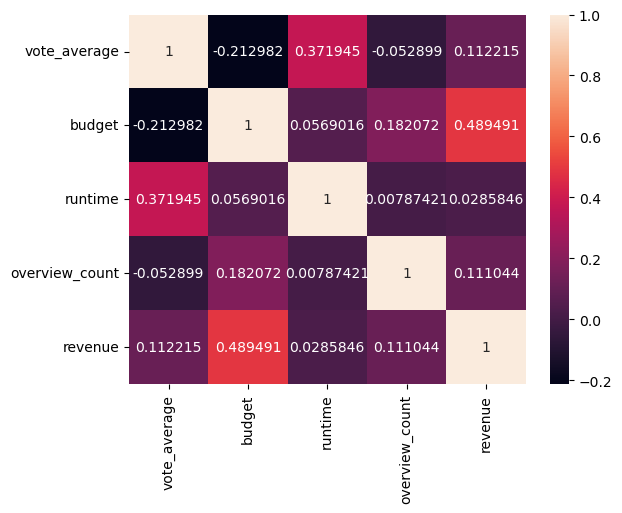

In [ ]:


corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count","revenue"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Si on rajoute main_genre_name_Drama :

/tmp/ipykernel_11127/1422207673.py:1: DeprecationWarning: bias and ddof have no effect and are deprecated
  corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue","main_genre_name_Drama"]].T, bias=True)


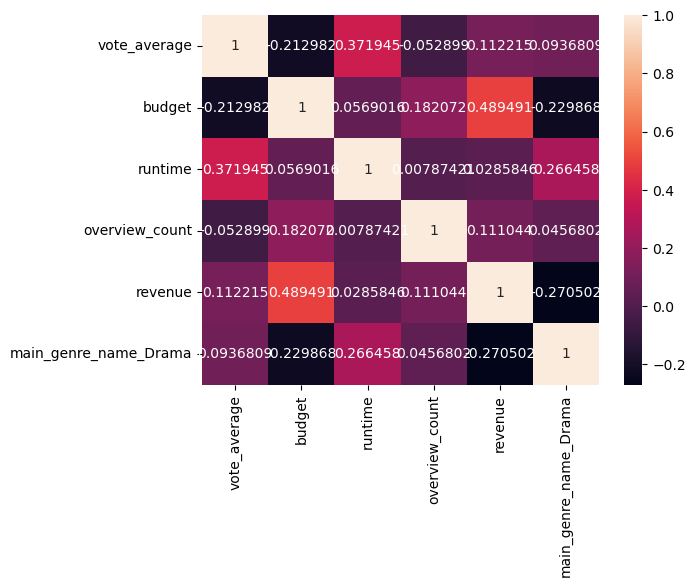

In [ ]:
corr = np.corrcoef(df1.loc[:,["vote_average","budget","runtime","overview_count","revenue","main_genre_name_Drama"]].T, bias=True)
labs = ['vote_average', 'budget', 'runtime',"overview_count","revenue","main_genre_name_Drama"]

sns.heatmap(corr, annot=True, fmt='g', xticklabels=labs, yticklabels=labs)
plt.show()

Normalisation et Standardisation des données : pas nécessaire dans la regression linéaire car le modèle ne sélectionne pas en fonction des poids, ce qui arrive dans les modèles de clustering. 

Régression linéaire :

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
X=df1.loc[:,~df1.columns.isin(['id', 'vote_average']) ]
#X=df1.loc[:,["budget","runtime","overview_count","revenue"] ]
Y=df1[["vote_average"]]
X.head()
Y.head()

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1) #80% de train
#X_train.shape
#X_test.shape

# Initialiser le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle avec l'ensemble d'entraînement
model.fit(X_train, Y_train)

# Prédire les résultats sur l'ensemble de test
Y_pred = model.predict(X_test)

# Afficher les coefficients de la régression linéaire
print("Coefficients de la régression linéaire :", model.coef_)
print("Ordonnée à l'origine (intercept) :", model.intercept_)

# Évaluer la performance du modèle
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Erreur quadratique moyenne (MSE) : {mse}")
print(f"Score R2 : {r2}")

Coefficients de la régression linéaire : [[-1.59728995e-08  1.57060096e-02 -3.33444132e-04  2.51614823e-09
  -1.12395902e-01 -1.09657727e-02  7.04092756e-01 -9.16181221e-02
  -2.86860315e-01 -9.54464019e-02 -9.34988033e-02 -4.56485874e-01
   8.36466128e-01  6.37565092e-01 -4.81749384e-01 -1.53838042e-01
  -1.67437938e-01  2.78053824e-01 -6.52191968e-02 -4.40662049e-01]]
Ordonnée à l'origine (intercept) : [5.26281736]
Erreur quadratique moyenne (MSE) : 0.48447177673772307
Score R2 : -0.11592891434546515


Distinguer les covariables ayant réellement un impact sur Y : (tests multiples de niveau 5%, rejet de H0 à tort au niv 5%) 

In [ ]:
import statsmodels.api as sm


# Ajouter une constante à X pour inclure l'intercept dans le modèle
X = sm.add_constant(X)

# Créer le modèle de régression linéaire
model = sm.OLS(Y, X).fit()  # OLS = Ordinary Least Squares (régression linéaire)

# Obtenir les résultats du modèle
summary = model.summary()

# Afficher le résumé qui contient les statistiques t de chaque covariable
print(summary)
r2 = model.rsquared
print(f"R² : {r2}")
# la différence de R2 entre statmodel et sklearn vient du fait qu'on entraine nos données sur 100% des données sur statmodel vs 80% sur sklearn 

#Afficher la T-stat pour runtime
T_stat_runtime=model.tvalues["runtime"]
print(T_stat_runtime)

#Zone de rejet de niveau 5% pour notre test d'hypothèse : 
from scipy.stats import norm
quantile = norm.ppf(1-5/200, loc=0, scale=1)
if T_stat_runtime >= quantile or T_stat_runtime <= - quantile : 
    print("le coef théorique devant runtime est trop proche de 0, on le rejete")
else: 
    print("on conserve la variable explicative runtime")


                            OLS Regression Results                            
Dep. Variable:           vote_average   R-squared:                       0.358
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     2.613
Date:                Tue, 10 Dec 2024   Prob (F-statistic):            0.00129
Time:                        10:24:20   Log-Likelihood:                -106.68
No. Observations:                 109   AIC:                             253.4
Df Residuals:                      89   BIC:                             307.2
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [ ]:
# Généralisation : 
var_explicative_significative_au_niv_5=[]
X.columns
for var_explicative in X.columns:
    if model.tvalues[var_explicative] >= quantile or model.tvalues[var_explicative] <= - quantile : 
        print("le coef théorique devant ", var_explicative , "est trop proche de 0, on le rejete")
    else: 
        print("on conserve la variable explicative:",var_explicative)
        var_explicative_significative_au_niv_5.append(var_explicative)
print(quantile)
print(var_explicative_significative_au_niv_5)
    

le coef théorique devant  const est trop proche de 0, on le rejete
le coef théorique devant  budget est trop proche de 0, on le rejete
le coef théorique devant  runtime est trop proche de 0, on le rejete
on conserve la variable explicative: overview_count
le coef théorique devant  revenue est trop proche de 0, on le rejete
on conserve la variable explicative: main_genre_name_Comedy
on conserve la variable explicative: main_genre_name_Romance
le coef théorique devant  main_genre_name_Animation est trop proche de 0, on le rejete
on conserve la variable explicative: main_genre_name_Drama
on conserve la variable explicative: main_genre_name_Fantasy
on conserve la variable explicative: main_genre_name_Adventure
on conserve la variable explicative: main_genre_name_Action
on conserve la variable explicative: main_genre_name_Crime
le coef théorique devant  main_genre_name_Western est trop proche de 0, on le rejete
le coef théorique devant  main_genre_name_Thriller est trop proche de 0, on le r

In [ ]:
from itertools import combinations

def generate_combinations(elements, k):
    """
    Génère toutes les combinaisons de k éléments dans une liste donnée.
    
    :param elements: Liste d'éléments (par exemple, une liste de variables).
    :param k: Nombre d'éléments à sélectionner.
    :return: Liste de tuples, chaque tuple représentant une combinaison.
    """
    return list(combinations(elements, k))



In [ ]:
print(var_explicative)

main_genre_name_Family


1
('overview_count',)


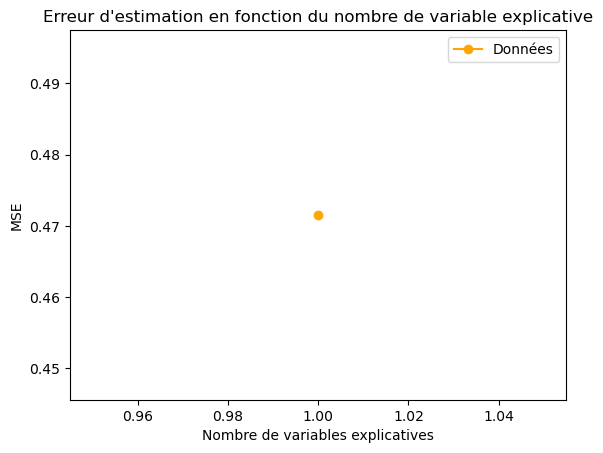

In [ ]:
X=X.loc[:,var_explicative_significative_au_niv_5[:7]] #On peut enlever [:7], ici sur nos données ca explose pour une certaines vraibles il va donc falloir l'enlever
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
a=[]
b=[]
for i in range(1,len(var_explicative_significative_au_niv_5[:7])+1): #On peut enlever [:7]
    print(i)
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5[:7], i) #On peut enlever [:7]
    L=[]
    for comb in combinations_list: 
        print(comb)
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
    a.append(i)
    b.append(min(L))

import matplotlib.pyplot as plt

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()

1
('overview_count',)


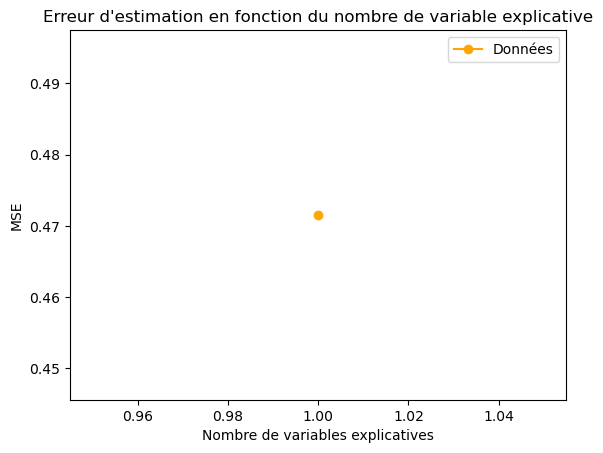

In [ ]:
X=X.loc[:,var_explicative_significative_au_niv_5] #On peut enlever [:7], ici sur nos données ca explose pour une certaines vraibles il va donc falloir l'enlever
X.head()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
a=[]
b=[]
for i in range(1,len(var_explicative_significative_au_niv_5)+1): #On peut enlever [:7]
    print(i)
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5, i) #On peut enlever [:7]
    L=[]
    for comb in combinations_list: 
        print(comb)
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()

        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)

        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])

        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        L.append(mse)
    a.append(i)
    b.append(min(L))

import matplotlib.pyplot as plt

# Créer un graphique avec une couleur personnalisée
plt.plot(a, b, color='orange', marker='o', linestyle='-', label='Données')  
# Ajouter des titres et des légendes
plt.title("Erreur d'estimation en fonction du nombre de variable explicative")
plt.xlabel("Nombre de variables explicatives")
plt.ylabel("MSE")
plt.legend()  # Affiche la légende

# Afficher le graphe
plt.show()

Il est donc clair qu'il n'est pas favorable d'ajouter toutes les variables explicatives. 

Var optimum : 

In [ ]:
X=X.loc[:,var_explicative_significative_au_niv_5] 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
comb_optimum=[]
mse_min=1
for i in range(1,len(var_explicative_significative_au_niv_5)+1): 
    combinations_list = generate_combinations(var_explicative_significative_au_niv_5, i) 
    for comb in combinations_list: 
        # Initialiser le modèle de régression linéaire
        model = LinearRegression()
        # Entraîner le modèle avec l'ensemble d'entraînement
        model.fit(X_train.loc[:,comb], Y_train)
        # Prédire les résultats sur l'ensemble de test
        Y_pred = model.predict(X_test.loc[:,comb])
        # Évaluer la performance du modèle
        mse = mean_squared_error(Y_test, Y_pred)
        if mse < mse_min:
            mse_min=mse
            comb_optimum=comb

print("Le mse min est : ",mse_min," et les variables explicatives permettant de l'atteindre sont : ",comb_optimum)

Le mse min est :  0.4715456133641778  et les variables explicatives permettant de l'atteindre sont :  ('overview_count',)


Méthode Lasso :